In [20]:
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import albumentations as A
import cv2
# from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from utils.Loader.myLoader import SegDataset
from torch.utils.data import DataLoader
import pickle
import torch
import random
# from PIL import Image
import numpy as np
import matplotlib.gridspec as gridspec
import os
os.makedirs("output/5-Model_explanation",exist_ok=True)
matplotlib.rcParams['pdf.fonttype'] = 42

In [21]:
TARGET_SIZE = (224, 224)

test_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    # Convert image and mask to PyTorch tensors
    A.ToTensorV2()
],seed=42)

batch_size = 16

In [38]:
with open('output/test_files.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
with open('output/train_files.pkl', 'rb') as file:
    loaded_data = pickle.load(file)

In [23]:
loaded_data

[{'image': 'Dataset/CHNCXR/CHNCXR_0088_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0088_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0114_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0114_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0044_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0044_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0177_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0177_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0011_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0011_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0104_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0104_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0033_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0033_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0125_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0125_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0012_0.png',
  'label': 'Dataset/CHNCXR_mask/CHNCXR_0012_0_mask.png'},
 {'image': 'Dataset/CHNCXR/CHNCXR_0075_0.png',
  'label

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device # check device

device(type='cuda')

In [25]:
model_select = 148
Unet_model = smp.from_pretrained(f'my_model/{model_select}').to(device)

Loading weights from local directory


In [26]:
target_layer = [Unet_model.encoder._blocks[-1]]
target_layer # check layer

[MBConvBlock(
   (_expand_conv): Conv2dStaticSamePadding(
     192, 1152, kernel_size=(1, 1), stride=(1, 1), bias=False
     (static_padding): Identity()
   )
   (_bn0): BatchNorm2d(1152, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
   (_depthwise_conv): Conv2dStaticSamePadding(
     1152, 1152, kernel_size=(3, 3), stride=[1, 1], groups=1152, bias=False
     (static_padding): ZeroPad2d((1, 1, 1, 1))
   )
   (_bn1): BatchNorm2d(1152, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
   (_se_reduce): Conv2dStaticSamePadding(
     1152, 48, kernel_size=(1, 1), stride=(1, 1)
     (static_padding): Identity()
   )
   (_se_expand): Conv2dStaticSamePadding(
     48, 1152, kernel_size=(1, 1), stride=(1, 1)
     (static_padding): Identity()
   )
   (_project_conv): Conv2dStaticSamePadding(
     1152, 320, kernel_size=(1, 1), stride=(1, 1), bias=False
     (static_padding): Identity()
   )
   (_bn2): BatchNorm2d(320, eps=0.001, m

In [39]:
sample = random.choice(loaded_data) # pick one sample randomly
sample

{'image': 'Dataset/CXR/011_hc.jpg', 'label': 'Dataset/Mask/011_hc_mask.jpg'}

In [40]:
test_dataset = SegDataset([sample], transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [29]:
# import matplotlib.gridspec as gridspec
# for image, mask, sample in test_loader:
#     print(mask.shape)
#     fig = plt.figure(figsize=(16, 4),dpi=300)
#     gs = gridspec.GridSpec(2, 6, height_ratios=[1, 0.05], hspace=0.05, wspace=0.1)

#     # Top row: images
#     ax0 = fig.add_subplot(gs[0,0])
#     ax1 = fig.add_subplot(gs[0,1])
#     ax2 = fig.add_subplot(gs[0,2])
#     ax3 = fig.add_subplot(gs[0,3])
#     ax4 = fig.add_subplot(gs[0,4])
#     ax5 = fig.add_subplot(gs[0,5])

#     ax1.imshow((mask.squeeze(0)[:,:,0]*255).numpy().astype(np.uint8), cmap="gray", interpolation="none")
#     ax1.set_title("Mask")
#     # ax1.axis("off")

#     ax2.imshow(mask.squeeze(0).numpy()[1], cmap="gray", interpolation="none")
#     ax2.set_title("Background")
#     ax2.axis("off")
#     plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
/work/rstudio_tmp/ipykernel_483807/1240861740.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


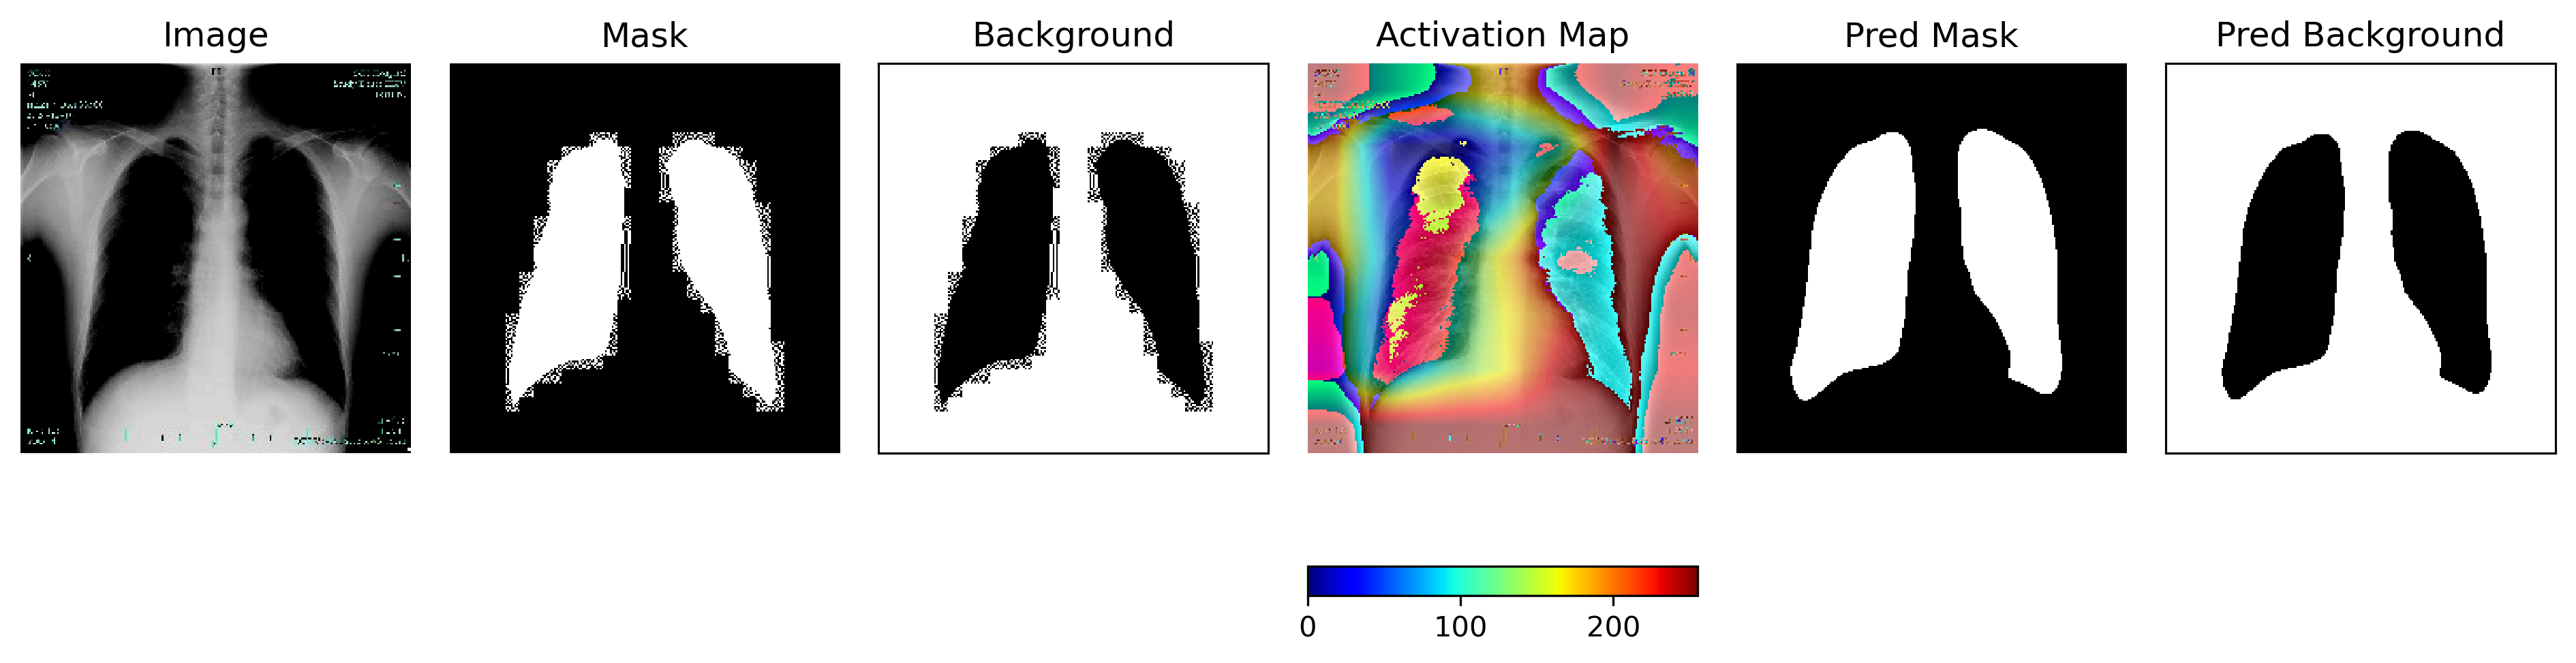

In [42]:
Unet_model.eval()
for image, mask, sample in test_loader:
    targets = [SemanticSegmentationTarget(0, mask[0,0].numpy())]
    # print(targets)
    outputs = Unet_model(image.to("cuda"))
    pred = (torch.sigmoid(outputs) > 0.5 ).float()
    with GradCAM(model=Unet_model, target_layers=target_layer) as cam:
        # grad_cam = GradCAM(model=model, target_layers=target_layer, targets=targets)
            # You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
        grayscale_cam = cam(input_tensor=image.to("cuda"), targets=targets)
        # print(grayscale_cam.shape)
        # In this example grayscale_cam has only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]
        # print(grayscale_cam.shape)
        # print(image.squeeze(0).permute(1,2,0).shape)
        visualization = show_cam_on_image(np.array(image.squeeze(0).permute(1,2,0).cpu().numpy().copy()), grayscale_cam, use_rgb=True)
        # plt.imshow(np.array(image.squeeze(0).permute(1,2,0)))
        # You can also get the model outputs without having to redo inference
        # model_outputs = cam.outputs
        # Image.fromarray(cam_image)
        cam_image = cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR)
        fig = plt.figure(figsize=(16, 4),dpi=300)
        gs = gridspec.GridSpec(2, 6, height_ratios=[1, 0.05], hspace=0.05, wspace=0.1)

        # Top row: images
        ax0 = fig.add_subplot(gs[0,0])
        ax1 = fig.add_subplot(gs[0,1])
        ax2 = fig.add_subplot(gs[0,2])
        ax3 = fig.add_subplot(gs[0,3])
        ax4 = fig.add_subplot(gs[0,4])
        ax5 = fig.add_subplot(gs[0,5])

        # Plot images
        ax0.imshow(image.squeeze(0).permute(1, 2, 0).numpy(), cmap="gray", interpolation="none")
        ax0.set_title("Image")
        ax0.axis("off")

        ax1.imshow(mask.squeeze(0).numpy()[0], cmap="gray", interpolation="none")
        ax1.set_title("Mask")
        ax1.axis("off")

        ax2.imshow(mask.squeeze(0).numpy()[1], cmap="gray", interpolation="none")
        ax2.set_title("Background")
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax2.spines["left"].set_linewidth(0.75)
        ax2.spines["right"].set_linewidth(0.75)
        ax2.spines["top"].set_linewidth(0.75)
        ax2.spines["bottom"].set_linewidth(0.75)

        im = ax3.imshow(cam_image, cmap="jet", interpolation="none")
        ax3.set_title("Activation Map")
        ax3.axis("off")
        # Bottom row: colorbar for this image
        cax = fig.add_subplot(gs[1,3])  # only under this image
        fig.colorbar(im, cax=cax, orientation="horizontal") # colorbar color based on "cmap", gradcam uses jet color map

        ax4.imshow(pred.squeeze(0).cpu().numpy()[0], cmap="gray", interpolation="none")
        ax4.set_title("Pred Mask")
        ax4.axis("off")

        ax5.imshow(pred.squeeze(0).cpu().numpy()[1], cmap="gray", interpolation="none")
        ax5.set_title("Pred Background")
        ax5.set_xticks([])
        ax5.set_yticks([])
        ax5.spines["left"].set_linewidth(0.75)
        ax5.spines["right"].set_linewidth(0.75)
        ax5.spines["top"].set_linewidth(0.75)
        ax5.spines["bottom"].set_linewidth(0.75)
        # ax5.axis("off")
        plt.tight_layout()
        plt.savefig(f"output/5-Model_explanation/Model{model_select}_explanation.pdf", format="pdf",bbox_inches = "tight")
        plt.show()